
# High-School Cybersecurity Standards, Evidence, and Pilot Analysis

This notebook analyzes **Foundations of Cybersecurity — 51-Jurisdiction Standards Matrix** and answers ten curriculum-design questions:

1. Expected high-school cybersecurity knowledge and skills
2. Standards recurring across jurisdictions
3. State-specific supplemental content and approval conditions
4. Teaching strategies for knowledge, application, retention, and transfer
5. Evidence specific to K–12 cybersecurity instruction
6. Transferable STEM and learning-science evidence
7. Feasible course structures for non-specialist teachers
8. Device, network, privacy, and safety constraints
9. Existing product coverage and underserved needs
10. Measurable pilot outcomes

**Interpretation boundary.** The workbook is a research and planning inventory. Exact state performance expectations are available for a subset of jurisdictions, so recurrence findings are strongest for the exact-standard subset and should not be represented as a complete 51-state legal crosswalk.


In [1]:

from pathlib import Path
import re
import warnings
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import display, Markdown

warnings.filterwarnings('ignore')
pd.set_option('display.max_colwidth', 140)
pd.set_option('display.max_rows', 100)

# Works when the notebook is kept beside the uploaded workbook.
preferred = Path('Foundations_of_Cybersecurity_51_Jurisdiction_Standards_Matrix(1) (1).xlsx')
if preferred.exists():
    WORKBOOK = preferred
else:
    matches = list(Path('.').glob('*51_Jurisdiction_Standards_Matrix*.xlsx')) + list(Path('/mnt/data').glob('*51_Jurisdiction_Standards_Matrix*.xlsx'))
    if not matches:
        raise FileNotFoundError('Place the 51-jurisdiction workbook beside this notebook or update WORKBOOK.')
    WORKBOOK = matches[0]

WORKBOOK


WindowsPath('Foundations_of_Cybersecurity_51_Jurisdiction_Standards_Matrix(1) (1).xlsx')

In [2]:

# Workbook tables begin on Excel row 5; rows 1–4 contain titles and notes.
SHEETS = [
    'State Matrix', 'State Exact Detail', 'National Standards', 'AP Benchmark',
    '20-Module Course', 'Module-Lesson Map', 'Semester Time Model',
    'Pedagogy Evidence', 'Research Sources', 'Competitor Matrix',
    'Approval Checklist', 'Codebook'
]

def read_table(sheet):
    return pd.read_excel(WORKBOOK, sheet_name=sheet, header=4)

data = {s: read_table(s) for s in SHEETS}
for name, df in data.items():
    df.dropna(how='all', inplace=True)
    df.columns = [str(c).strip() for c in df.columns]

summary = pd.DataFrame({
    'sheet': data.keys(),
    'rows': [len(x) for x in data.values()],
    'columns': [len(x.columns) for x in data.values()]
})
display(summary)


ImportError: Missing optional dependency 'openpyxl'.  Use pip or conda to install openpyxl.

## 1. What cybersecurity knowledge and skills are expected of high-school students?

In [ ]:

national = data['National Standards'].copy()
state_exact = data['State Exact Detail'].copy()
ap = data['AP Benchmark'].copy()

# Focus state records on high-school grade bands where they are explicitly identifiable.
hs_pattern = r'9|10|11|12|high school|9–12|9-12'
hs_state = state_exact[state_exact['Grade Band'].astype(str).str.contains(hs_pattern, case=False, regex=True, na=False)].copy()

national_domains = (national.groupby(['Concept / Domain','Course Domain'], dropna=False)
                    .size().reset_index(name='standards')
                    .sort_values('standards', ascending=False))
display(national_domains.head(20))

skill_verbs = ['analyze','apply','assess','build','compare','configure','create','design','develop','evaluate','explain','identify','implement','investigate','model','monitor','protect','troubleshoot','use']
text = pd.concat([
    national['Performance Expectation'].dropna(),
    hs_state['Performance Expectation'].dropna(),
    ap['Learning Objective'].dropna()
]).astype(str)
verb_counts = {v: text.str.lower().str.contains(rf'\b{v}\w*\b', regex=True).sum() for v in skill_verbs}
verb_df = pd.DataFrame({'performance_verb': verb_counts.keys(), 'expectations': verb_counts.values()}).sort_values('expectations', ascending=False)
display(verb_df.head(15))

expected_summary = pd.DataFrame({
    'Expected domain / capability': [
        'Networks and computing systems', 'Security principles and risk', 'Threats and social engineering',
        'Identity and access control', 'Data protection, privacy, and cryptography',
        'System/device hardening and vulnerability management', 'Monitoring, incident response, and resilience',
        'Ethics, authorization, policy, and societal impact', 'Communication, collaboration, and career awareness'
    ],
    'Student performance': [
        'Explain architectures, protocols, services, cloud tradeoffs, and troubleshoot data flow.',
        'Apply confidentiality, integrity, availability, threat modeling, risk assessment, and control selection.',
        'Recognize indicators, explain attacker motives/tactics, and design user-centered mitigations.',
        'Compare authentication, authorization, least privilege, roles, and account-security controls.',
        'Protect data at rest/in transit/in use; reason about privacy, PII, encryption, hashing, and backups.',
        'Configure and justify updates, secure settings, endpoint/network controls, and remediation priorities.',
        'Interpret evidence, document incidents, recommend containment/recovery, and plan redundancy.',
        'Operate only with authorization; reason about responsible disclosure, acceptable use, law, equity, and impacts.',
        'Create diagrams, logs, policies, code/configurations, decision memos, and briefings; connect work to careers.'
    ]
})
display(expected_summary)


,Concept / Domain,Course Domain,standards
0,Computing Systems,"Backup, redundancy, recovery",1
1,Computing Systems,Cloud and shared responsibility,1
2,Computing Systems,Device and system hardening,1
3,Computing Systems,IoT and embedded risk,1
4,Computing Systems,Logging and monitoring,1
5,Computing Systems,Network architecture,1
6,Computing Systems,Networking fundamentals / OSI,1
7,Computing Systems,OS hardening,1
8,Computing Systems,Patching and change risk,1
9,Computing Systems,Protocol risk,1


,performance_verb,expectations
10,explain,35
11,identify,33
0,analyze,21
16,protect,17
9,evaluate,14
18,use,13
1,apply,9
4,compare,9
12,implement,7
2,assess,5


,Expected domain / capability,Student performance
0,Networks and computing systems,"Explain architectures, protocols, services, cloud tradeoffs, and troubleshoot data flow."
1,Security principles and risk,"Apply confidentiality, integrity, availability, threat modeling, risk assessment, and control selection."
2,Threats and social engineering,"Recognize indicators, explain attacker motives/tactics, and design user-centered mitigations."
3,Identity and access control,"Compare authentication, authorization, least privilege, roles, and account-security controls."
4,"Data protection, privacy, and cryptography","Protect data at rest/in transit/in use; reason about privacy, PII, encryption, hashing, and backups."
5,System/device hardening and vulnerability management,"Configure and justify updates, secure settings, endpoint/network controls, and remediation priorities."
6,"Monitoring, incident response, and resilience","Interpret evidence, document incidents, recommend containment/recovery, and plan redundancy."
7,"Ethics, authorization, policy, and societal impact","Operate only with authorization; reason about responsible disclosure, acceptable use, law, equity, and impacts."
8,"Communication, collaboration, and career awareness","Create diagrams, logs, policies, code/configurations, decision memos, and briefings; connect work to careers."



**Answer.** The expected profile is not merely “cyber awareness.” Students are expected to combine conceptual understanding with observable performance: model systems, analyze risks and evidence, configure or select controls, troubleshoot, communicate decisions, and act within ethical and authorized boundaries. The national standards and AP benchmark reinforce a progression from recognition and explanation to analysis, mitigation, creation, and justification.


## 2. Which standards recur across jurisdictions?

,Cybersecurity Domain,jurisdictions,exact_expectations
0,Privacy / PII,5,33
1,Authentication & Access Control,5,25
2,Security Controls & Risk Management,5,15
3,Threats & Social Engineering,4,16
4,Cryptography,4,13
5,Threats & Malware,3,6
6,Updates & Patch Management,2,12
7,Incident Recognition & Response,2,7
8,Threats & Vulnerabilities,2,5
9,Network Security,2,3


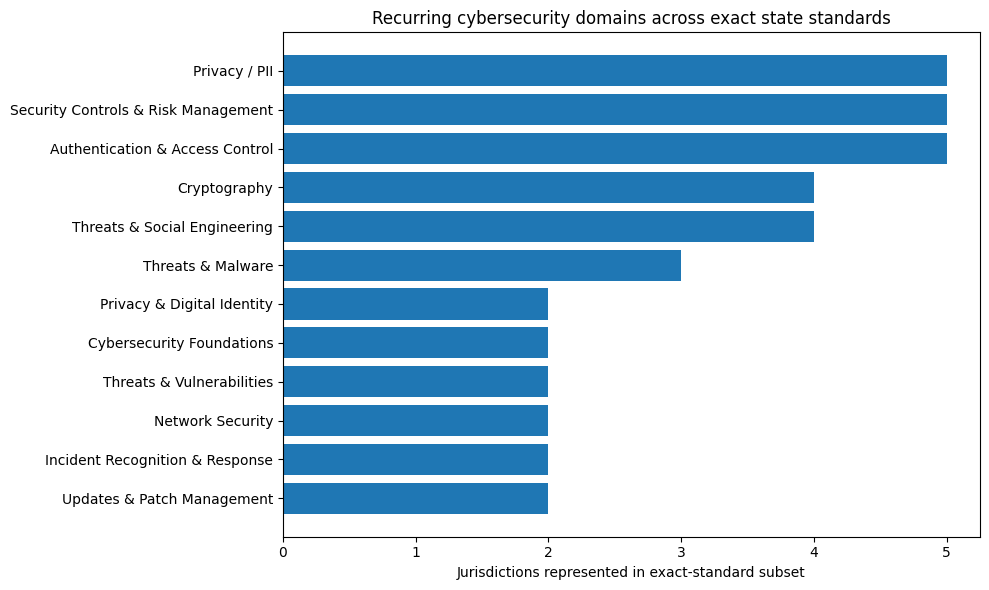

,Strand / Subconcept,jurisdictions,expectations
0,Networks and the Internet — Cybersecurity,3,46


In [ ]:

# The most defensible cross-jurisdiction recurrence analysis uses the workbook's normalized cybersecurity domain.
domain_recurrence = (state_exact.dropna(subset=['State','Cybersecurity Domain'])
    .groupby('Cybersecurity Domain')
    .agg(jurisdictions=('State','nunique'), exact_expectations=('Standard ID','count'))
    .sort_values(['jurisdictions','exact_expectations'], ascending=False)
    .reset_index())
display(domain_recurrence)

plt.figure(figsize=(10,6))
plot_df = domain_recurrence.head(12).sort_values('jurisdictions')
plt.barh(plot_df['Cybersecurity Domain'], plot_df['jurisdictions'])
plt.xlabel('Jurisdictions represented in exact-standard subset')
plt.title('Recurring cybersecurity domains across exact state standards')
plt.tight_layout()
plt.show()

# Also show repeated strands/subconcepts, which retain more state wording.
strand_recurrence = (state_exact.dropna(subset=['State','Strand / Subconcept'])
    .groupby('Strand / Subconcept')
    .agg(jurisdictions=('State','nunique'), expectations=('Standard ID','count'))
    .query('jurisdictions >= 2')
    .sort_values(['jurisdictions','expectations'], ascending=False)
    .reset_index())
display(strand_recurrence.head(25))



**Answer.** Across the exact-standard subset, the recurring core is typically: privacy and personal information; authentication/access control; threats and social engineering; safe use and security practices; networks and systems; data protection; updates/patching and device security; and ethical or societal impacts. More advanced high-school frameworks add cryptography, vulnerability analysis, incident response, resilience, cloud risk, and security architecture. Because many jurisdictions have only source-level inventory records, these counts describe the decomposed subset—not all 51 jurisdictions.


## 3. Which state-specific standards or approval conditions require supplemental content?

In [ ]:

state_matrix = data['State Matrix'].copy()
cols = ['Jurisdiction','Classification','Confidence','Cyber specificity','Course-use decision','Caution / filing check',
        'Sequence / concentrator','Assessment / technical standard','Approval / Perkins / CLNA','Credentials / WBL','Exact rows','Exact crosswalk status']
state_review = state_matrix[cols].copy()

# Flag common supplemental/approval needs from the explicit decision and caution fields.
patterns = {
    'local course code / credit': r'course code|credit|graduation|classification',
    'exact state overlay': r'exact|crosswalk|identifier|mapping',
    'teacher credential / assignment': r'teacher|license|endorsement|assignment',
    'CTE / Perkins / CLNA approval': r'perkins|clna|cte|program approval|sequence|cip',
    'assessment / credential': r'assessment|credential|certification|technical standard',
    'device / network / lab approval': r'device|network|lab|range|equipment|security review',
    'privacy / accessibility / AI governance': r'privacy|accessibility|ai governance|data governance'
}
combined = state_review.fillna('').astype(str).agg(' | '.join, axis=1).str.lower()
flag_table = pd.DataFrame({'Jurisdiction': state_review['Jurisdiction']})
for label, pat in patterns.items():
    flag_table[label] = combined.str.contains(pat, regex=True)
flag_table['number_of_flag_types'] = flag_table.drop(columns='Jurisdiction').sum(axis=1)

display(flag_table.sort_values('number_of_flag_types', ascending=False).head(20))

# Jurisdictions with named courses/pathways often need specific overlays rather than a generic national mapping.
named_or_cte = state_review[state_review['Classification'].astype(str).str.startswith(('A','B'))]
display(named_or_cte[['Jurisdiction','Classification','Course-use decision','Caution / filing check','Exact crosswalk status']])

approval = data['Approval Checklist'][['ID','Category','Required evidence']]
display(approval)


,Jurisdiction,local course code / credit,exact state overlay,teacher credential / assignment,CTE / Perkins / CLNA approval,assessment / credential,device / network / lab approval,privacy / accessibility / AI governance,number_of_flag_types
12,Idaho,True,True,False,True,True,True,True,6
32,New York,True,True,False,True,True,True,True,6
22,Michigan,True,True,True,True,True,True,False,6
27,Nebraska,True,True,True,True,True,True,False,6
30,New Jersey,True,True,False,True,True,True,True,6
16,Kansas,True,True,False,True,True,True,False,5
9,Florida,True,True,False,True,True,True,False,5
18,Louisiana,True,True,False,True,True,True,False,5
5,Colorado,True,True,False,True,True,True,False,5
13,Illinois,True,True,False,True,True,True,False,5


,Jurisdiction,Classification,Course-use decision,Caution / filing check,Exact crosswalk status
3,Arkansas,B — State cybersecurity/IT CTE pathway,Use as a direct state-course model; crosswalk each local unit to the Arkansas document and current state course-coding rules.,Confirm whether a newer Standards for Accreditation/course code document supersedes this file.,Source inventory only — exact standard decomposition unresolved
4,California,B — State cybersecurity/IT CTE pathway,Align to the high-school standards and local ICT pathway; add CSTA/CYBER.ORG detail for a dedicated cyber course.,California course approval and UC/CSU A–G treatment require separate local review.,Exact rows available in this workbook
7,Delaware,B — State cybersecurity/IT CTE pathway,Use the state pathway sequence and local technical-skills attainment rules; insert cyber-specific national standards by module.,"Verify current pathway version, course names, and dual-enrollment articulation.",Source inventory only — exact standard decomposition unresolved
10,Georgia,A — State-named cybersecurity course or course standard,Use the CASE standard identifiers and current Georgia course catalog; treat 11.48100 as a direct state-course comparator.,Confirm the current course-standard document attached to 11.48100 before an approval filing.,Source inventory only — exact standard decomposition unresolved
11,Hawaii,B — State cybersecurity/IT CTE pathway,Cite the version of CSTA currently recognized by HIDOE and the local CTE program standards.,Confirm whether HIDOE has formally moved from CSTA 2017 to CSTA 2026 before using new identifiers for compliance.,Source inventory only — exact standard decomposition unresolved
14,Indiana,B — State cybersecurity/IT CTE pathway,"Use course 5251 as an advanced comparator, not as the default intro model; reduce prerequisites and technical depth for an entry course.",Confirm current Next Level Programs of Study course title/code and prerequisite rules.,Source inventory only — exact standard decomposition unresolved
16,Kansas,B — State cybersecurity/IT CTE pathway,Crosswalk the course to high-school model standards; identify district adoption status.,Model standards may not have the same force as required state content standards; verify locally.,Source inventory only — exact standard decomposition unresolved
17,Kentucky,B — State cybersecurity/IT CTE pathway,Use the high-school standards and the selected local CTE pathway's technical standards.,Confirm the current CTE course sequence and end-of-program assessment locally.,Source inventory only — exact standard decomposition unresolved
18,Louisiana,B — State cybersecurity/IT CTE pathway,Use the exact locally selected state course document; add CSTA Specialty I only after the Louisiana outcomes are mapped.,"The KS3001 file is an official course document, but confirm its title, current status, and applicable course code before filing.",Exact rows available in this workbook
26,Montana,B — State cybersecurity/IT CTE pathway,Use high-school standards plus national cyber standards for a complete semester scope.,Confirm local credit and CTE pathway placement.,Source inventory only — exact standard decomposition unresolved


,ID,Category,Required evidence
0,1,Course identity,"Title, description, grade span, prerequisites, credit value, minimum instructional time"
1,2,Course coding,"State course code, NCES SCED code, local code, subject/department classification"
2,3,Graduation treatment,"Elective/CTE/CS/math/science credit, substitution eligibility, applicable student cohort"
3,4,Standards,"Exact identifier, exact expectation, grade band, version, adoption/effective date, required/recommended status"
4,5,Mapping evidence,"Module, lesson, assessment artifact, full/partial/supporting/gap rating"
5,6,Teacher assignment,"License, endorsement, assignment code, exception, professional-learning expectation"
6,7,CTE program,"Sequence, pathway position, CIP code, Perkins eligibility, CLNA/local plan connection"
7,8,Technical assessment,"Required or optional credential, assessment code, testing rules, pass threshold"
8,9,WBL and CTSO,"Work-based learning, CTSO participation, capstone, advisory committee, articulation"
9,10,Facilities,"Device specifications, virtualization, cyber range, software, network isolation, egress controls"



**Answer.** Supplemental work falls into two categories:

- **Content overlays:** exact state identifiers; state-specific digital citizenship/privacy expectations; named cybersecurity-course outcomes; CTE technical standards; career/credential, work-based learning, or AI-related requirements; and gaps where the national core does not fully address a state expectation.
- **Approval evidence:** course code and credit treatment, instructional minutes, teacher assignment/endorsement, pathway sequence and CIP/Perkins/CLNA alignment, technical assessment or credential rules, accessibility, privacy/data governance, district security review, lab authorization, and version/effective-date verification.

The notebook flags likely conditions from the workbook, but each filing still requires review of operative state and district sources.


## 4–6. Teaching strategies and evidence base

In [ ]:

ped = data['Pedagogy Evidence'].copy()
research = data['Research Sources'].copy()
display(ped)
display(research)

strategy_outcomes = pd.DataFrame([
    ['Knowledge acquisition','Scenario-first explanation, worked examples, explicit vocabulary, concept maps','Build accurate mental models before tool use.'],
    ['Application','Modeled → guided → independent isolated labs; authentic artifacts and rubrics','Students apply controls and explain evidence, not merely follow steps.'],
    ['Retention','Spaced retrieval, cumulative checks, interleaving, delayed posttests','Revisit concepts across modules and measure after a delay.'],
    ['Transfer','Novel scenario variants, compare cases, reflection, fading scaffolds, capstone briefing','Require students to select and justify methods in unfamiliar contexts.'],
    ['Motivation','Short CTF/game challenges after instruction; meaningful roles and inclusive contexts','Use engagement as practice, not as a substitute for curriculum.'],
    ['Implementation fidelity','Prebuilt labs, troubleshooting trees, answer keys, misconception notes, rehearsal','Reduce dependence on deep teacher cybersecurity expertise.']
], columns=['Outcome','Recommended strategy','Design implication'])
display(strategy_outcomes)


,Practice,Evidence synthesis,Course design rule,Evidence strength / caveat
0,"Scenario-first, problem-centered instruction","Systematic and design literature supports authentic, contextual problems; the supplied high-school guideline and AP framework consistent...",Open each module with a consequential scenario; end with an evidence-backed decision or artifact.,Moderate; outcome studies remain heterogeneous.
1,Scaffolded hands-on labs in isolated environments,Quasi-experimental and virtual-lab studies report knowledge and self-efficacy gains; cyber-range/game reviews warn that engagement alone...,Use concept briefing → modeled example → guided lab → independent variation → explanation; never target public systems.,Moderate for proximal learning; limited long-term/transfer evidence.
2,"CTF and games as retrieval/application, not the entire course","CTFs can increase interest and provide authentic problem solving, while reviews find uneven learning design and shallow conceptual cover...","Use short challenges after instruction and a capstone competition; score reasoning, evidence, and reflection in addition to flags.",Promising but mixed.
3,Authentic performance assessment,"Course and CTE quality standards emphasize observable competencies, aligned assessment, feedback, and real-world application.","Require logs, diagrams, code, policies, incident timelines, and briefings with analytic rubrics.",Strong design consensus; cyber-specific causal evidence is limited.
4,"Spaced retrieval, interleaving, and delayed retention",General learning science strongly supports retrieval and spacing; the high-school cyber evidence base rarely measures delayed retention.,"Use cumulative checks every module, mixed-domain labs every four modules, and a delayed post-course measure.",Strong general evidence; cyber-specific implementation evidence needed.
5,Collaborative roles plus individual accountability,"Cyber learning is collaborative, but group-composition effects can alter self-efficacy and interest.","Rotate analyst, operator, recorder, and briefer roles; collect an individual explanation from every student.",Moderate.
6,"Low floor, high ceiling, and belonging-centered design","CSTA/AI4K12 and pathway guidance prioritize inclusive collaboration, accessible entry points, relevant contexts, and belonging.","Provide novice path, extension path, multiple artifact formats, accessible labs, and culturally relevant scenarios without lowering stan...",Strong expert consensus; measure subgroup outcomes.
7,Teacher enablement and stable lab operations,"Program-quality and online-course standards identify professional development, support, usability, and technology reliability as impleme...","Provide prebuilt environments, troubleshooting trees, answer keys, misconception notes, safety scripts, and implementation rehearsals.",Strong implementation consensus.


,Study,Relevant finding,Source URL
0,Ibrahim et al. — Cybersecurity education for children: a systematic literature review,Reviewed 24 academic and 19 gray-literature sources; secondary-level work dominates and cybersecurity is not taught systematically acros...,https://ro.ecu.edu.au/ecuworks2022-2026/3929/
1,Namukasa et al. — Hands-on IoT cybersecurity course,"Quasi-experimental middle/high-school study reported significant knowledge gains, F(1,16)=15.76, p=.001, partial eta squared=.496; self-...",https://digitalcommons.kennesaw.edu/jcerp/vol2025/iss1/9/
2,Konak — inquiry-based virtual cybersecurity lab,Hands-on inquiry lab reported significant learning progress and gains in self-efficacy; supports guided experimentation with reflection.,https://digitalcommons.kennesaw.edu/jcerp/vol2018/iss1/6/
3,Coenraad et al. — Cybersecurity games systematic review,Many games use thin narratives and surface-level cyber-safety content; fewer support deep conceptual engagement or inquiry.,https://journals.sagepub.com/doi/10.1177/1046878120933312
4,Systematic scoping review of game-based cybersecurity education,Games and ranges can support learning when aligned to objectives and assessment; adaptive difficulty and valid mastery measures remain i...,https://doi.org/10.1007/s10207-026-01239-9
5,CSTA Standards Alignment Review (supplied PDF),"Popular curricula overrepresent algorithms/programming and underrepresent computing systems, networks, and cybersecurity; the course sho...",Standards-Alignment-Review.pdf


,Outcome,Recommended strategy,Design implication
0,Knowledge acquisition,"Scenario-first explanation, worked examples, explicit vocabulary, concept maps",Build accurate mental models before tool use.
1,Application,Modeled → guided → independent isolated labs; authentic artifacts and rubrics,"Students apply controls and explain evidence, not merely follow steps."
2,Retention,"Spaced retrieval, cumulative checks, interleaving, delayed posttests",Revisit concepts across modules and measure after a delay.
3,Transfer,"Novel scenario variants, compare cases, reflection, fading scaffolds, capstone briefing",Require students to select and justify methods in unfamiliar contexts.
4,Motivation,Short CTF/game challenges after instruction; meaningful roles and inclusive contexts,"Use engagement as practice, not as a substitute for curriculum."
5,Implementation fidelity,"Prebuilt labs, troubleshooting trees, answer keys, misconception notes, rehearsal",Reduce dependence on deep teacher cybersecurity expertise.



### Evidence interpretation

**K–12-specific evidence.** The workbook identifies a small and uneven base: systematic reviews show secondary-level work dominates and school cybersecurity is not yet systematic; a middle/high-school hands-on IoT course reported a large proximal knowledge gain; an inquiry-based virtual lab reported learning and self-efficacy gains; and game/CTF reviews find promising engagement but inconsistent conceptual depth, adaptive support, and mastery measurement. Long-term retention and far transfer are rarely measured.

**Reasonably transferable evidence.** General STEM and learning science strongly support retrieval practice, spacing, interleaving, worked examples followed by scaffold fading, formative feedback, problem/project-based learning, contextualized authentic tasks, and individual accountability within collaboration. Transfer should be claimed cautiously: these principles support course design, but cybersecurity-specific replication and delayed measures are still needed.


## 7. Which course structures are feasible for teachers without deep cybersecurity backgrounds?

In [ ]:

course = data['20-Module Course'].copy()
time_model = data['Semester Time Model'].copy()
display(time_model)
display(course[['Module','Title','Primary evidence','State overlay action']])

teacher_feasible = pd.DataFrame([
    ['Default semester','20 modules × 3 lessons; about 60 core periods plus assessment, reteach, lab setup, and capstone time','Best balance of breadth, repetition, and manageable preparation.'],
    ['Block schedule','20 modules × 3 ninety-minute blocks','Allows concept briefing, guided lab, and reflection in one block.'],
    ['Compressed local option','About 55 hours only where local policy permits','Requires reduced lab variation and careful prioritization; not a universal half-credit claim.'],
    ['Extended/credential feeder','90–150+ hours','Supports more practice or credential preparation, but exceeds a typical foundations semester.']
], columns=['Structure','Design','Feasibility conclusion'])
display(teacher_feasible)


,Model,Periods,Minutes each,Total minutes,Hours,Use / constraint
0,Compressed implementation,60,55,3300,55.00,Only where local policy accepts this instructional time for 0.5 credit; no national approval claim.
1,Daily semester,90,55,4950,82.50,"Default design: 60 module periods plus 30 lab, assessment, reteach, and capstone periods."
2,90-hour expansion,98,55,5390,89.83,Add eight documented studio/assessment periods where a 90-hour target is required; verify exact state/local rule.
3,Block schedule equivalent,60,90,5400,90.00,"Twenty modules × three 90-minute lesson blocks; account separately for calendar, testing, and interruptions."


,Module,Title,Primary evidence,State overlay action
0,1,"Cybersecurity, ethics, authorization, and careers",Ethics/authorization decision memo,"Add exact state identifiers and classify each mapping as full, partial, supporting, or gap."
1,2,"Computing systems, abstraction, and decomposition",System and trust-boundary model,"Add exact state identifiers and classify each mapping as full, partial, supporting, or gap."
2,3,Networking foundations and the OSI model,Annotated network diagram,"Add exact state identifiers and classify each mapping as full, partial, supporting, or gap."
3,4,"Protocols, ports, services, and troubleshooting",Troubleshooting log,"Add exact state identifiers and classify each mapping as full, partial, supporting, or gap."
4,5,Security principles and threat modeling,Threat model and control rationale,"Add exact state identifiers and classify each mapping as full, partial, supporting, or gap."
5,6,"Threat actors, social engineering, and human risk",Social-engineering analysis,"Add exact state identifiers and classify each mapping as full, partial, supporting, or gap."
6,7,"Identity, authentication, and access control",Access-control audit,"Add exact state identifiers and classify each mapping as full, partial, supporting, or gap."
7,8,Cryptography and secure communication,Cryptography explanation,"Add exact state identifiers and classify each mapping as full, partial, supporting, or gap."
8,9,Operating systems and endpoint hardening,Hardened endpoint baseline,"Add exact state identifiers and classify each mapping as full, partial, supporting, or gap."
9,10,"Software, patching, vulnerabilities, and disclosure",Patch/disclosure brief,"Add exact state identifiers and classify each mapping as full, partial, supporting, or gap."


,Structure,Design,Feasibility conclusion
0,Default semester,"20 modules × 3 lessons; about 60 core periods plus assessment, reteach, lab setup, and capstone time","Best balance of breadth, repetition, and manageable preparation."
1,Block schedule,20 modules × 3 ninety-minute blocks,"Allows concept briefing, guided lab, and reflection in one block."
2,Compressed local option,About 55 hours only where local policy permits,Requires reduced lab variation and careful prioritization; not a universal half-credit claim.
3,Extended/credential feeder,90–150+ hours,"Supports more practice or credential preparation, but exceeds a typical foundations semester."



**Answer.** The most feasible structure is a stable repeated lesson routine inside a 20-module semester: **scenario and concept briefing → modeled example → guided isolated lab → independent variation → artifact/explanation → cumulative retrieval**. Teacher supports should include preconfigured environments, concise content primers, scripts for safety and authorization, worked solutions, troubleshooting decision trees, rubrics, misconception notes, and optional extensions. A semester course should be positioned as a foundation or feeder—not automatic AP equivalence or full credential preparation.


## 8. Device, network, privacy, and safety constraints affecting hands-on work

In [ ]:

approval_text = ' '.join(data['Approval Checklist']['Required evidence'].dropna().astype(str))
course_text = ' '.join(course.fillna('').astype(str).agg(' '.join, axis=1))
competitor_text = ' '.join(data['Competitor Matrix'].fillna('').astype(str).agg(' '.join, axis=1))

constraints = pd.DataFrame([
    ['Authorization and scope','All activity must be defensive, explicitly authorized, and restricted to provided targets.'],
    ['Network isolation','Use local VMs/containers, simulations, packet captures, or an approved cyber range; never scan or attack public or district production systems.'],
    ['Device capability','Check RAM/storage, virtualization support, admin rights, browser restrictions, OS compatibility, accessibility, and 1:1 versus shared-device realities.'],
    ['Filtering and connectivity','Document domains, ports, downloads, proxies, certificates, firewall rules, and offline fallbacks before launch.'],
    ['Student privacy','Minimize accounts and personal data; define retention, vendor access, telemetry, consent, and deletion; avoid real student credentials or sensitive records in labs.'],
    ['Safety and misuse prevention','Provide lab compact, least-privilege accounts, resettable environments, logging, teacher visibility, controlled datasets, and incident escalation procedures.'],
    ['Equity and accessibility','Offer keyboard-accessible materials, captions/alt text, low-bandwidth or offline paths, and alternatives when virtualization or home access is unavailable.'],
    ['AI governance','Define allowed uses, data restrictions, attribution, verification, and safeguards against submitting secrets or personal information to AI tools.']
], columns=['Constraint','Operational requirement'])
display(constraints)


,Constraint,Operational requirement
0,Authorization and scope,"All activity must be defensive, explicitly authorized, and restricted to provided targets."
1,Network isolation,"Use local VMs/containers, simulations, packet captures, or an approved cyber range; never scan or attack public or district production s..."
2,Device capability,"Check RAM/storage, virtualization support, admin rights, browser restrictions, OS compatibility, accessibility, and 1:1 versus shared-de..."
3,Filtering and connectivity,"Document domains, ports, downloads, proxies, certificates, firewall rules, and offline fallbacks before launch."
4,Student privacy,"Minimize accounts and personal data; define retention, vendor access, telemetry, consent, and deletion; avoid real student credentials o..."
5,Safety and misuse prevention,"Provide lab compact, least-privilege accounts, resettable environments, logging, teacher visibility, controlled datasets, and incident e..."
6,Equity and accessibility,"Offer keyboard-accessible materials, captions/alt text, low-bandwidth or offline paths, and alternatives when virtualization or home acc..."
7,AI governance,"Define allowed uses, data restrictions, attribution, verification, and safeguards against submitting secrets or personal information to ..."


## 9. What do existing products cover, and what do they leave underserved?

In [ ]:

comp = data['Competitor Matrix'].copy()
display(comp[['Provider / route','Duration','Strengths','Implementation burden','Product positioning']])

coverage_gap = pd.DataFrame([
    ['Hosted lessons, auto-grading, and ranges','CodeHS and similar platforms','Approval-grade exact state overlays and transparent version control.'],
    ['No-cost curriculum, standards, range, and PD','CYBER.ORG','Turnkey semester packaging, district filing artifacts, assessment analytics, and local implementation support.'],
    ['Networking/career pathway depth','Cisco Networking Academy','Academic standards mapping, broad privacy/policy/ethics coverage, and district-ready evidence.'],
    ['Authentic hardening and competition','CyberPatriot','Complete semester scope, conceptual progression, equitable access, privacy/policy/AI, and valid assessment.'],
    ['Rigorous yearlong academic benchmark','AP Cybersecurity','Broad-access semester alternative/feeder for schools unable to implement AP requirements.'],
    ['Credential objectives and employment signal','Pearson/industry credentials','A realistic semester foundation without overpromising 150-hour credential readiness.']
], columns=['Commonly covered','Examples','Underserved opportunity'])
display(coverage_gap)


,Provider / route,Duration,Strengths,Implementation burden,Product positioning
0,AP Cybersecurity,Yearlong; 2026–27 launch,"Detailed five-unit framework, three assessed technical skill categories, collaboration including AI, scenario connections, external AP b...","AP authorization, teacher/school readiness, yearlong schedule, cyber-range access, AP assessment alignment.",Use the proposed semester course as a broad-access feeder or non-AP alternative; do not imply AP equivalence.
1,CodeHS,Semester and full-year options; Alberti intro listed at 90 contact hours; AP listed at 130 contact hours,"Hosted LMS, many variants, automatic grading, cyber-range/labs, published alignments.","Licensing, platform procurement, local alignment validation, device/network requirements.","Differentiate with approval-grade evidence packs, exact state overlays, transparent version control, and flexible offline/isolated labs."
2,CYBER.ORG,Cybersecurity 1/2 listed as 180 hours; Cyber Society about 90 hours,"No-cost access, standards, professional development, cyber range, national reach.","Teacher onboarding, local course packaging and approval, range/network approvals.","Compete on complete semester packaging, state submission artifacts, assessment analytics, AI literacy, and implementation support—not on..."
3,Cisco Networking Academy,Intro to Cybersecurity is a short beginner course; longer career pathways available,"Global brand, networking depth, career pathway, instructor ecosystem.",Academy/platform setup; short intro is not by itself a semester approval package.,"Offer stronger academic standards mapping, pedagogy, student artifacts, and district-approval evidence."
4,CyberPatriot,Seasonal competition; not a full semester curriculum,"Authentic OS hardening/networking tasks, motivation, teamwork, national visibility.","Coach time, competition logistics, uneven access; narrower content coverage.","Integrate optional CyberPatriot-style capstones while preserving complete foundational CS, policy, privacy, AI, and assessment coverage."
5,Pearson IT Specialist — Cybersecurity,Objectives recommend approximately 150 hours of instruction and hands-on experience,Clear five-domain credential target and employment signal.,"Exam fees, testing center/logistics, substantial instructional time, credential-driven scope.",Use as an optional extended-course credential target; a semester foundation should not promise full 150-hour preparation.


,Commonly covered,Examples,Underserved opportunity
0,"Hosted lessons, auto-grading, and ranges",CodeHS and similar platforms,Approval-grade exact state overlays and transparent version control.
1,"No-cost curriculum, standards, range, and PD",CYBER.ORG,"Turnkey semester packaging, district filing artifacts, assessment analytics, and local implementation support."
2,Networking/career pathway depth,Cisco Networking Academy,"Academic standards mapping, broad privacy/policy/ethics coverage, and district-ready evidence."
3,Authentic hardening and competition,CyberPatriot,"Complete semester scope, conceptual progression, equitable access, privacy/policy/AI, and valid assessment."
4,Rigorous yearlong academic benchmark,AP Cybersecurity,Broad-access semester alternative/feeder for schools unable to implement AP requirements.
5,Credential objectives and employment signal,Pearson/industry credentials,A realistic semester foundation without overpromising 150-hour credential readiness.



**Answer.** Existing products cover many individual pieces well—hosted curriculum, ranges, networking pathways, competitions, standards, professional development, AP rigor, or credentials. The clearest underserved bundle is a **nationally adaptable semester foundation** that combines exact and versioned state overlays, approval/submission artifacts, safe flexible labs (including offline/isolated options), strong teacher enablement, privacy and AI governance, inclusive design, and pilot-ready assessment analytics.


## 10. What outcomes can we measure during a pilot?

In [ ]:

pilot_metrics = pd.DataFrame([
    ['Knowledge','Standards-aligned pre/post assessment; domain subscores; normalized gain','Before and after course'],
    ['Application','Rubric scores for network diagrams, threat models, access audits, configs, logs, incident timelines, and policy/briefing artifacts','Each module/capstone'],
    ['Retention','Parallel delayed assessment and selected repeated tasks','4–8 weeks after instruction/course'],
    ['Transfer','Novel scenario requiring method selection, evidence interpretation, mitigation, and justification','Midpoint and capstone'],
    ['Safety/ethics','Authorization, scope, privacy, and responsible-disclosure decisions in scenario rubrics; lab violations/near misses','Continuous'],
    ['Self-efficacy and interest','Brief validated or carefully piloted scales; career awareness; belonging','Pre/mid/post, disaggregated'],
    ['Engagement and completion','Attendance, module completion, challenge attempts, time-on-task, revision rate','Continuous'],
    ['Teacher feasibility','Preparation time, support requests, troubleshooting time, lesson completion, confidence, fidelity checklist','Weekly/post'],
    ['Technical feasibility','Login success, environment launch rate, blocked domains/ports, device failures, reset frequency, lab uptime','Each lab'],
    ['Equity and accessibility','Access failures, accommodations used, completion and growth by subgroup, student experience','Continuous/post'],
    ['Implementation and approval readiness','Coverage of required standards, evidence artifacts completed, checklist items resolved','Before and after pilot'],
    ['Cost and scalability','Licenses, devices, teacher PD/support hours, cost per completer, reusable setup effort','End of pilot']
], columns=['Outcome family','Example measures','Timing'])
display(pilot_metrics)


,Outcome family,Example measures,Timing
0,Knowledge,Standards-aligned pre/post assessment; domain subscores; normalized gain,Before and after course
1,Application,"Rubric scores for network diagrams, threat models, access audits, configs, logs, incident timelines, and policy/briefing artifacts",Each module/capstone
2,Retention,Parallel delayed assessment and selected repeated tasks,4–8 weeks after instruction/course
3,Transfer,"Novel scenario requiring method selection, evidence interpretation, mitigation, and justification",Midpoint and capstone
4,Safety/ethics,"Authorization, scope, privacy, and responsible-disclosure decisions in scenario rubrics; lab violations/near misses",Continuous
5,Self-efficacy and interest,Brief validated or carefully piloted scales; career awareness; belonging,"Pre/mid/post, disaggregated"
6,Engagement and completion,"Attendance, module completion, challenge attempts, time-on-task, revision rate",Continuous
7,Teacher feasibility,"Preparation time, support requests, troubleshooting time, lesson completion, confidence, fidelity checklist",Weekly/post
8,Technical feasibility,"Login success, environment launch rate, blocked domains/ports, device failures, reset frequency, lab uptime",Each lab
9,Equity and accessibility,"Access failures, accommodations used, completion and growth by subgroup, student experience",Continuous/post



### Recommended minimum pilot design

Use a standards-aligned pre/post knowledge measure, at least two common performance tasks, a delayed retention check, and one novel transfer scenario. Pair student outcomes with teacher-preparation time, technical failure logs, safety events, and subgroup results. Preserve artifacts and rubric rows so results can support both learning claims and course-approval evidence. Avoid relying only on satisfaction, completion, flags captured, or self-efficacy.


## Executive synthesis

In [ ]:

executive = pd.DataFrame([
    ['Curriculum target','A broad cybersecurity foundation combining systems/networks, risk, identity, data protection, hardening, monitoring/response, ethics, privacy, communication, and careers.'],
    ['Common standards spine','Privacy, authentication, threats/social engineering, safe security practices, networks/systems, data protection, device updates/hardening, and societal/ethical impacts.'],
    ['Localization burden','Exact state mapping, named-course or CTE additions, course code/credit, teacher assignment, hours, pathway/Perkins, assessment/credentials, privacy/accessibility/security approvals.'],
    ['Instructional model','Scenario-first explicit instruction with scaffolded isolated labs, authentic artifacts, cumulative retrieval, novel transfer tasks, and individual accountability.'],
    ['Evidence confidence','Promising but limited K–12 cyber-specific causal evidence; stronger transferable learning-science and STEM design evidence.'],
    ['Feasible implementation','20-module semester with repeated routines, prebuilt labs, teacher guides, troubleshooting support, and flexible device/network modes.'],
    ['Market gap','Approval-ready, version-controlled, teacher-friendly, safe and accessible semester packaging with state overlays and outcome analytics.'],
    ['Pilot proof points','Knowledge, authentic performance, delayed retention, transfer, safety/ethics, teacher feasibility, technical reliability, equity, approval readiness, and cost.']
], columns=['Decision area','Conclusion'])
display(executive)


,Decision area,Conclusion
0,Curriculum target,"A broad cybersecurity foundation combining systems/networks, risk, identity, data protection, hardening, monitoring/response, ethics, pr..."
1,Common standards spine,"Privacy, authentication, threats/social engineering, safe security practices, networks/systems, data protection, device updates/hardenin..."
2,Localization burden,"Exact state mapping, named-course or CTE additions, course code/credit, teacher assignment, hours, pathway/Perkins, assessment/credentia..."
3,Instructional model,"Scenario-first explicit instruction with scaffolded isolated labs, authentic artifacts, cumulative retrieval, novel transfer tasks, and ..."
4,Evidence confidence,Promising but limited K–12 cyber-specific causal evidence; stronger transferable learning-science and STEM design evidence.
5,Feasible implementation,"20-module semester with repeated routines, prebuilt labs, teacher guides, troubleshooting support, and flexible device/network modes."
6,Market gap,"Approval-ready, version-controlled, teacher-friendly, safe and accessible semester packaging with state overlays and outcome analytics."
7,Pilot proof points,"Knowledge, authentic performance, delayed retention, transfer, safety/ethics, teacher feasibility, technical reliability, equity, approv..."



## Reproducibility notes

- All tables and counts are generated from the uploaded workbook.
- The workbook’s own codebook distinguishes an exact standard from a source inventory; this notebook preserves that boundary.
- URLs and source references remain in the workbook tables. For formal decisions, verify current operative sources and local district requirements.
- Recurrence results will update automatically if more exact state standards are added to **State Exact Detail**.
